<a href="https://colab.research.google.com/github/GhalaAwd/Computer-Vision-Capstone-Project/blob/main/notebooks/05_dashboard_export.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/GhalaAwd/Computer-Vision-Capstone-Project/blob/main/notebooks/05_dashboard_export.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dashboard, Timeline Report & Model Export

Loads the pipeline outputs, exports the trained gesture model to ONNX, and renders
the post-lecture analytics dashboard and delivery-timeline report.

## Setup

In [15]:
import os
REPO = "Computer-Vision-Capstone-Project"
if not os.path.exists(REPO):
    !git clone -q https://github.com/GhalaAwd/{REPO}.git
%cd {REPO}

/content/Computer-Vision-Capstone-Project/Computer-Vision-Capstone-Project/Computer-Vision-Capstone-Project


In [16]:
%pip install -q ultralytics streamlit pillow
import sys
sys.path.insert(0, "src")   # make the project modules importable

## Load the pipeline outputs

`build_report_data()` reads the presenter keypoints, the per-clip coverage stats and
images, and the per-second body-language metrics, and unifies them into one object.

In [17]:
from dashboard_data import build_report_data

data = build_report_data(outputs_dir="outputs", models_dir="models")

print(f"Clips loaded: {len(data.clips)}\n")
for c in data.clips:
    stab = f"{c.stability_mean:.1f}" if c.stability_mean is not None else "n/a"
    cov  = f"{c.coverage_pct}%" if c.coverage_pct is not None else "n/a"
    print(f"{c.clip:18s} {c.duration_s:>3d}s  stability={stab:>5s}  "
          f"gestures/min={c.gestures_per_minute:>5.1f}  "
          f"movement={c.movement_energy_mean:>6.1f}px/s  coverage={cov}")

Clips loaded: 3

clip1_presenter     17s  stability= 80.6  gestures/min= 11.0  movement= 234.1px/s  coverage=9.0%
clip2_presenter      9s  stability= 92.3  gestures/min=  7.1  movement= 175.9px/s  coverage=2.0%
clip3_presenter     14s  stability= 97.2  gestures/min= 18.1  movement= 233.7px/s  coverage=6.0%


## Export the trained gesture model to ONNX

ONNX is a portable, framework-agnostic format: the exported model runs under ONNX
Runtime with no PyTorch dependency at serve time, which keeps deployment lightweight
and CPU-friendly.

Make the trained weights available first, either by mounting Google Drive and pointing
`PT_WEIGHTS` at the file, or by uploading `gesture_detector_best.pt` into `models/`.

In [18]:
%cd /content/Computer-Vision-Capstone-Project

/content/Computer-Vision-Capstone-Project


In [19]:
from pathlib import Path
import shutil

# Point this at the trained weights.
# Drive example:
#   from google.colab import drive; drive.mount("/content/drive")
#   PT_WEIGHTS = "/content/drive/MyDrive/capstone_repo/models/gesture_detector_best.pt"
PT_WEIGHTS = "models/gesture_detector_best.pt"

if not Path(PT_WEIGHTS).exists():
    raise FileNotFoundError(
        f"{PT_WEIGHTS} not found. Mount Google Drive or upload the trained weights "
        "into models/ before running this cell."
    )

local_pt = Path("models/gesture_detector_best.pt")
if Path(PT_WEIGHTS).resolve() != local_pt.resolve():
    shutil.copy(PT_WEIGHTS, local_pt)
print("Using weights:", local_pt)

Using weights: models/gesture_detector_best.pt


In [20]:
from ultralytics import YOLO

model = YOLO(str(local_pt))
onnx_path = model.export(format="onnx")

print("Exported to:", onnx_path)
!ls -lh models/*.onnx

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from 'models/gesture_detector_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 1.03s
Prepared 4 packages in 3.55s
Insta

## Analytics report & delivery timeline

`build_html_report()` renders the summary cards, the synced per-second delivery
timeline (posture stability, movement energy, and gesture moments on one strip), the
spatial-coverage visuals, and the gesture-model card into one self-contained HTML file.

In [21]:
from report_builder import build_html_report, delivery_timeline_fig

report_path = build_html_report(data, "outputs/mentorvision_report.html")
print("Report written:", report_path, f"({report_path.stat().st_size/1024:.0f} KB)")

Report written: outputs/mentorvision_report.html (630 KB)



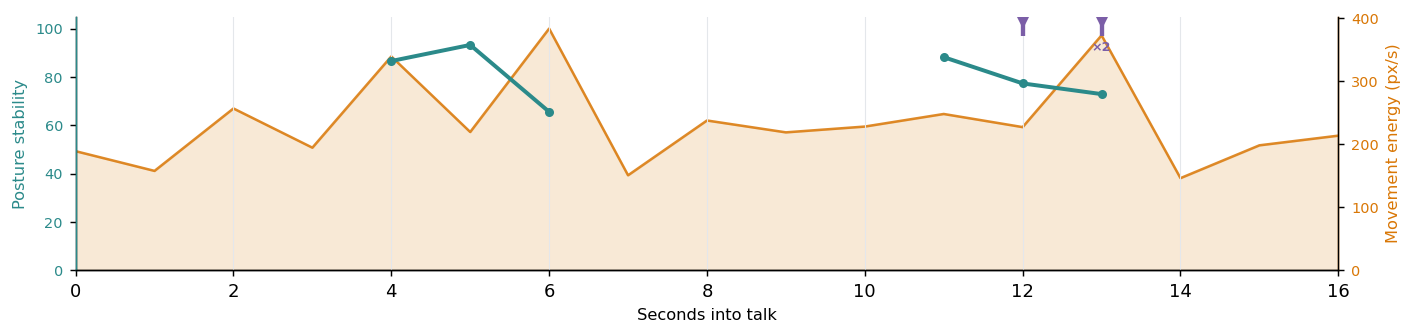
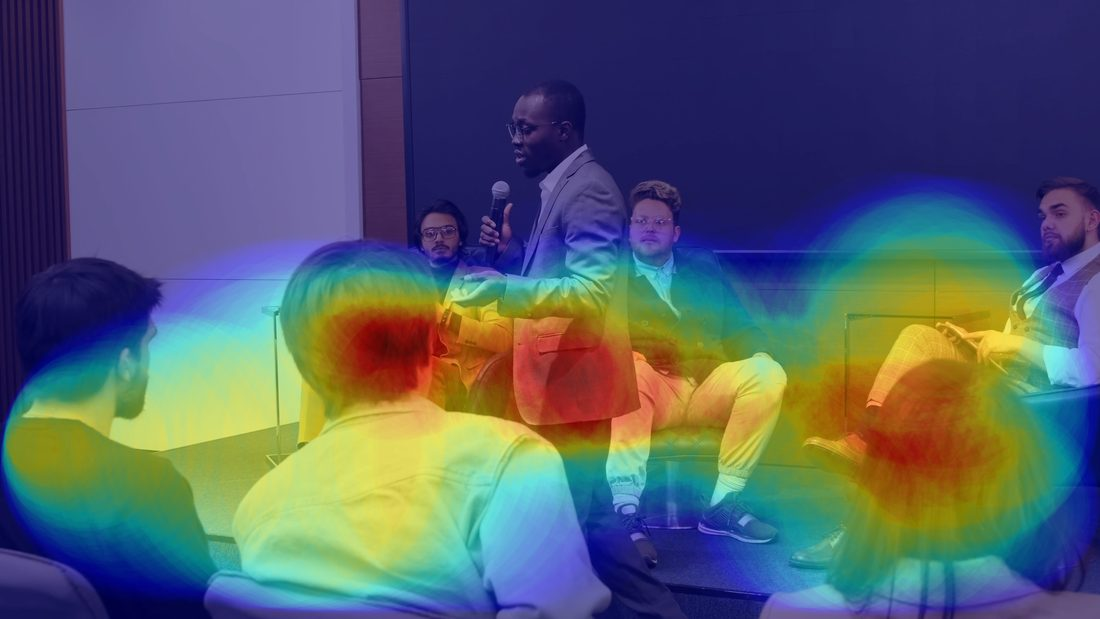
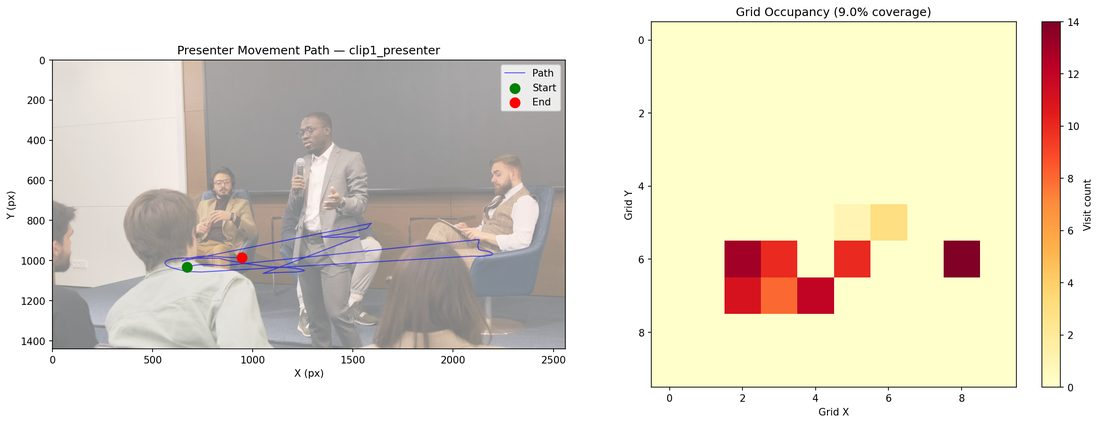
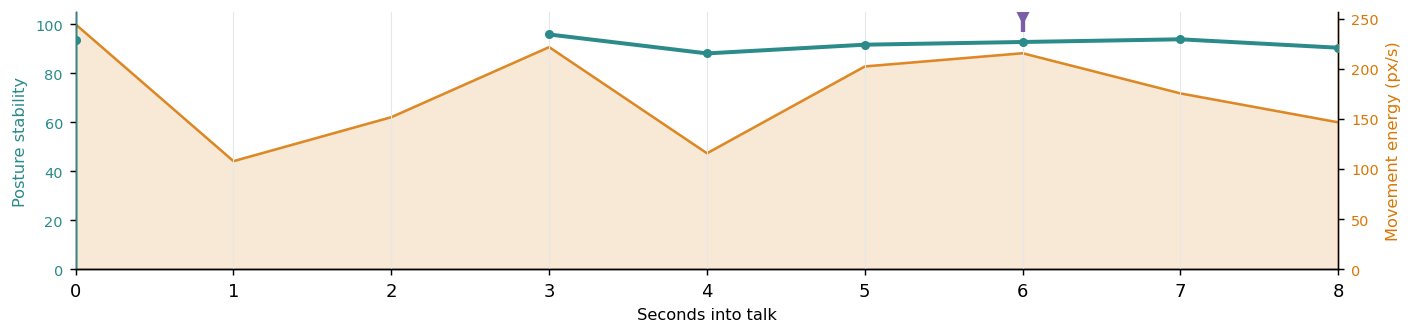
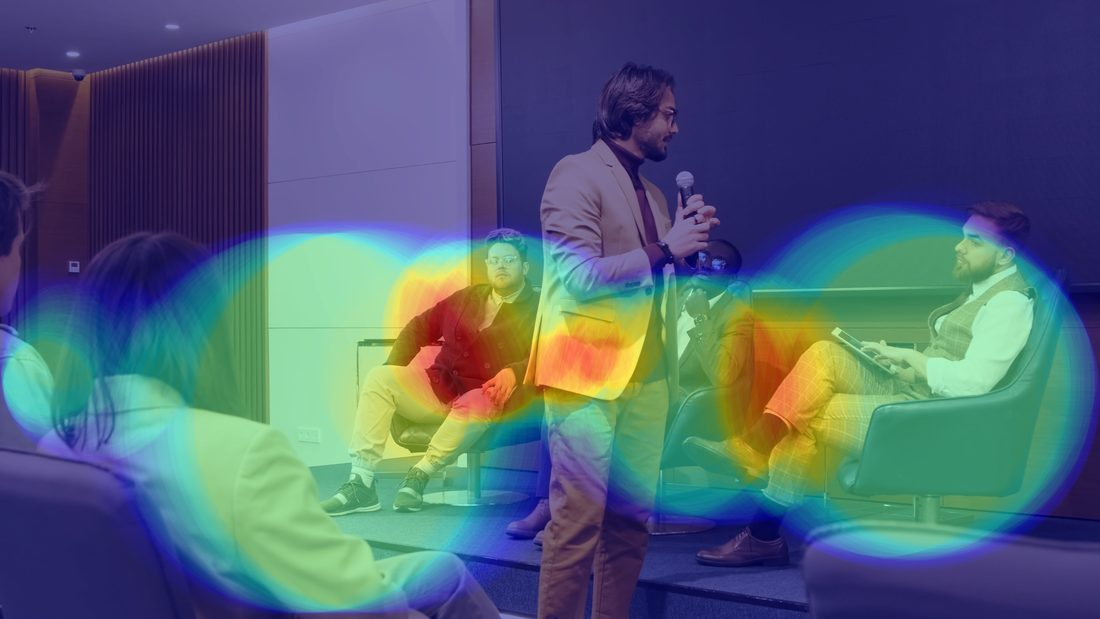
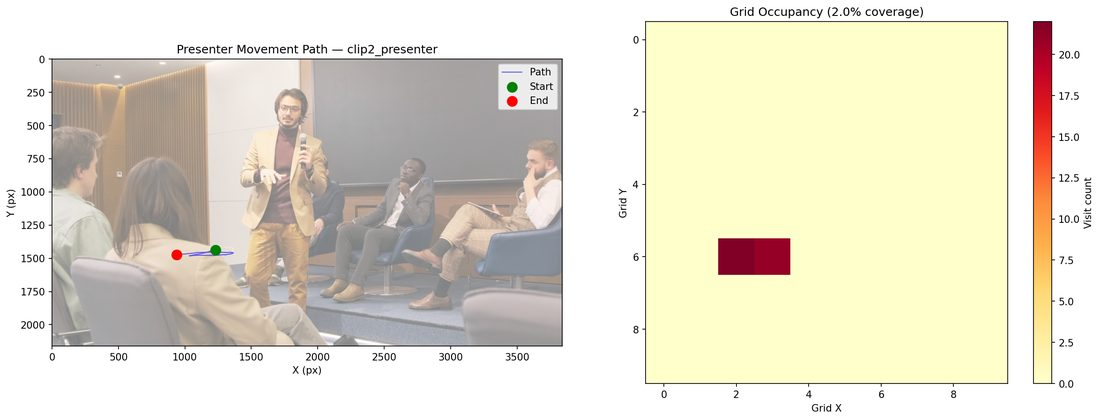
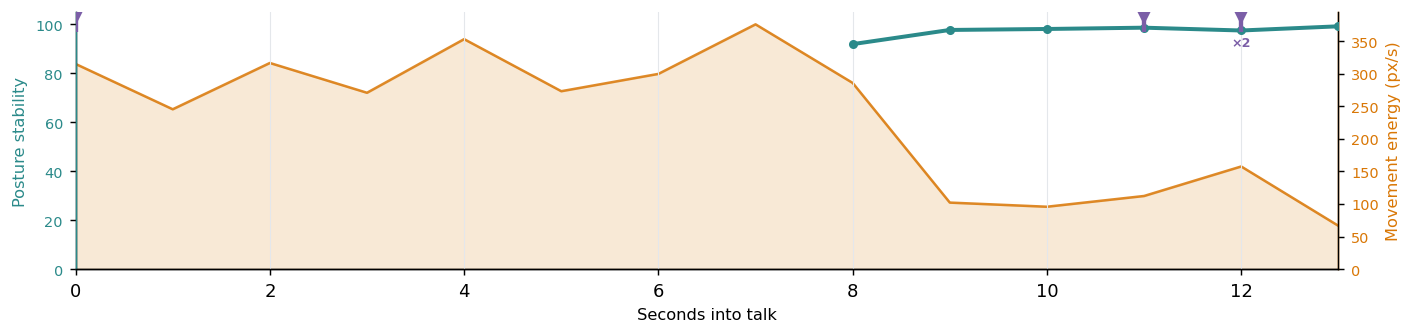
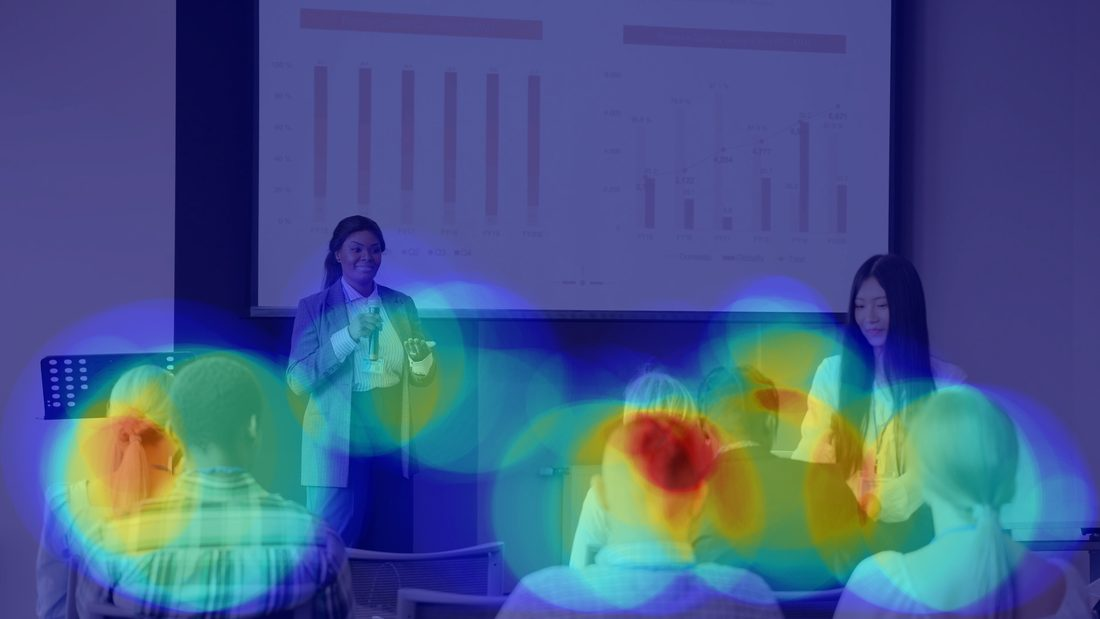
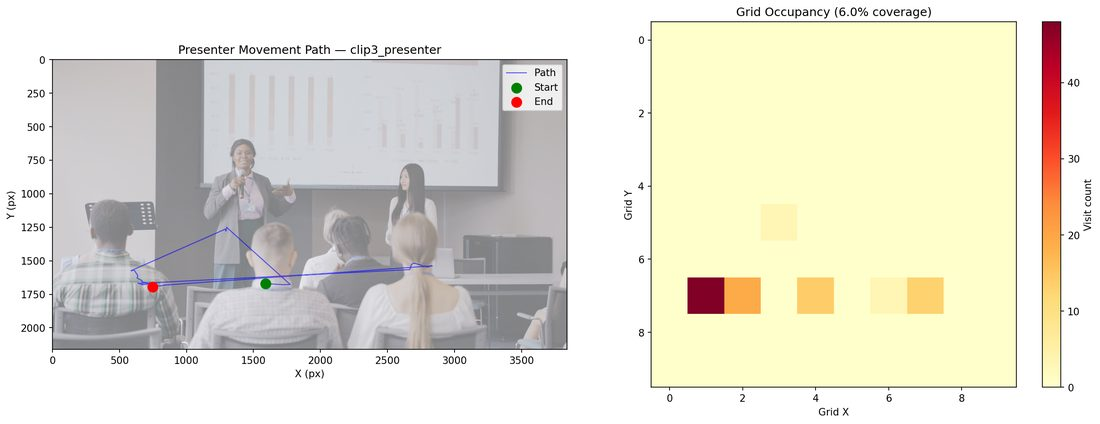

In [22]:
from IPython.display import HTML
HTML(open("outputs/mentorvision_report.html").read())

In [23]:
import matplotlib.pyplot as plt
for c in data.clips:
    print(c.clip)
    delivery_timeline_fig(c)
    plt.show()

clip1_presenter
clip2_presenter
clip3_presenter


## Interactive dashboard

The Streamlit app is the interactive companion to the report. On Colab it is reached
through a tunnel: run the cell, open the printed URL, and enter the tunnel password
(the printed external IP).

In [ ]:
!npm install -q -g localtunnel 2>/dev/null
!streamlit run src/dashboard.py --server.port 8501 --server.headless true &>/content/st.log &
import time; time.sleep(6)
print("Tunnel password (external IP):")
!curl -s https://loca.lt/mytunnelpassword; print()
!npx localtunnel --port 8501